## 04 — RETREINO, TESTE CEGO E RELATÓRIO
**Objetivo**: retreinar o **melhor modelo** de cada algoritmo (CART e RN) com as 10.000 vítimas do **dataset de treino/validação**, avaliar os dois no **dataset de teste cego** e gerar o relatório com as tabelas 1 a 7 e os gráficos de dispersão.

**Entradas**
* `results/dataset.json`, `results/cart.json` e `results/rn.json`: saídas dos notebooks 01, 02 e 03
* `datasets/vict/10000v/data.csv`: o dataset de treino/validação (retreino)
* `datasets/vict/teste_cego/data.csv`: o dataset de teste cego, lido **somente** neste notebook

**Saídas**
* `results/melhor_cart.joblib`: o CART retreinado
* `results/scaler.joblib` e `results/melhor_rn.joblib`: o `StandardScaler` ajustado nas 10.000 vítimas e a RN treinada com os dados escalados
* `results/relatorio.html`: o relatório autocontido (tabelas 1 a 7 e gráficos embutidos), para imprimir como PDF

**(1) Leitura dos resultados da validação cruzada**

Os três JSONs trazem tudo o que o relatório precisa das etapas anteriores: os valores da tabela 1 (`dataset.json`), as hiperparametrizações e os resultados do CART (tabelas 2 e 3) e da RN (tabelas 4 e 5), e o rótulo do melhor modelo de cada algoritmo.

In [1]:
import base64
import html
import io
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# Caminhos
RESULTS_DIR = Path("results")
DATASET_CSV = Path("datasets/vict/10000v/data.csv")
TESTE_CEGO_CSV = Path("datasets/vict/teste_cego/data.csv")

CART_JOBLIB = RESULTS_DIR / "melhor_cart.joblib"
SCALER_JOBLIB = RESULTS_DIR / "scaler.joblib"
RN_JOBLIB = RESULTS_DIR / "melhor_rn.joblib"
RELATORIO_HTML = RESULTS_DIR / "relatorio.html"

def le_json(nome):
    with open(RESULTS_DIR / nome, encoding='utf-8') as f:
        return json.load(f)

dataset_res = le_json("dataset.json")
cart_res = le_json("cart.json")
rn_res = le_json("rn.json")

melhor_cart = cart_res['melhor']
melhor_rn = rn_res['melhor']

assert dataset_res['n_vitimas'] == 10000
assert set(cart_res['resultados']) == set(rn_res['resultados']) == {'U', 'E', 'O'}
assert melhor_cart in cart_res['hiperparametrizacoes'] and melhor_rn in rn_res['hiperparametrizacoes']

print(f"Melhor CART.:\t{melhor_cart} ({cart_res['hiperparametrizacoes'][melhor_cart]['nome']})")
print(f"Melhor RN...:\t{melhor_rn} ({rn_res['hiperparametrizacoes'][melhor_rn]['nome']})")

Melhor CART.:	E (Equilibrada)
Melhor RN...:	E (Equilibrada)


**(2) Leitura do dataset de treino/validação**

As mesmas 10.000 vítimas usadas na validação cruzada. X recebe somente as 10 features de entrada (as mesmas gravadas nos JSONs); gcs, avpu e tri são **features proibidas** e sobr é o alvo.

In [2]:
FEATURES_ENTRADA = ['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']
FEATURES_PROIBIDAS = ['gcs', 'avpu', 'tri', 'sobr']  # sobr é o alvo
ALVO = 'sobr'

assert cart_res['features_entrada'] == rn_res['features_entrada'] == FEATURES_ENTRADA
assert cart_res['alvo'] == rn_res['alvo'] == ALVO

df = pd.read_csv(DATASET_CSV)
assert len(df) == 10000, f"esperado 10000 vítimas, obtido {len(df)}"

X = df[FEATURES_ENTRADA]
y = df[ALVO]

# Nenhuma feature proibida (nem o alvo) pode entrar em X
assert not set(FEATURES_PROIBIDAS) & set(X.columns), f"feature proibida em X: {set(FEATURES_PROIBIDAS) & set(X.columns)}"
assert list(X.columns) == FEATURES_ENTRADA

print(f"Arquivo.....:\t{DATASET_CSV}")
print(f"Vítimas.....:\t{len(X):>6}")
print(f"Features (X):\t{list(X.columns)}")
print(f"Alvo (y)....:\t{ALVO}  [{y.min():.4f}, {y.max():.4f}]")

Arquivo.....:	datasets/vict/10000v/data.csv
Vítimas.....:	 10000
Features (X):	['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']
Alvo (y)....:	sobr  [0.0500, 1.0000]


**(3) Retreino do melhor CART**

**Retreino**: a melhor hiperparametrização do CART é ajustada com as 10.000 vítimas inteiras, sem validação cruzada nem split. Os hiperparâmetros vêm do `cart.json` (só as chaves que o `DecisionTreeRegressor` aceita; `nome` é o rótulo da tabela).

In [3]:
def params_do_json(hp, estimador):
    # Mantém só os hiperparâmetros que o estimador aceita (descarta 'nome', 'n_camadas_ocultas'...)
    validos = estimador().get_params()
    return {k: v for k, v in hp.items() if k in validos}

hp_cart = params_do_json(cart_res['hiperparametrizacoes'][melhor_cart], DecisionTreeRegressor)

cart = DecisionTreeRegressor(**hp_cart)
cart.fit(X, y)
joblib.dump(cart, CART_JOBLIB)

print(f"Melhor CART ({melhor_cart}): {cart}")
print(f"Profundidade: {cart.get_depth()}\tFolhas: {cart.get_n_leaves()}")
print(f"MSE de treino (10.000 vítimas): {mean_squared_error(y, cart.predict(X)):.6f}")
print(f"Salvo em {CART_JOBLIB}")

Melhor CART (E): DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
Profundidade: 10	Folhas: 272
MSE de treino (10.000 vítimas): 0.001957
Salvo em results/melhor_cart.joblib


**(4) Retreino da melhor RN**

Na validação cruzada o `StandardScaler` ficava dentro do `Pipeline`, para ser ajustado só com o treino de cada fold. No retreino não há folds: o scaler é ajustado com as 10.000 vítimas e salvo **separado** (`scaler.joblib`), e a RN é treinada com os dados escalados (`melhor_rn.joblib`), como pede a entrega do enunciado.

`hidden_layer_sizes` volta a ser tupla (o JSON grava listas).

In [4]:
hp_rn = params_do_json(rn_res['hiperparametrizacoes'][melhor_rn], MLPRegressor)
hp_rn['hidden_layer_sizes'] = tuple(hp_rn['hidden_layer_sizes'])

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

rn = MLPRegressor(**hp_rn)
rn.fit(X_escalado, y)

joblib.dump(scaler, SCALER_JOBLIB)
joblib.dump(rn, RN_JOBLIB)

print(f"Melhor RN ({melhor_rn}): {rn}")
print(f"Épocas: {rn.n_iter_} (max_iter = {hp_rn['max_iter']})")
print(f"MSE de treino (10.000 vítimas): {mean_squared_error(y, rn.predict(X_escalado)):.6f}")
print(f"Salvos em {SCALER_JOBLIB} e {RN_JOBLIB}")

Melhor RN (E): MLPRegressor(activation='tanh', alpha=0.01, hidden_layer_sizes=(64, 32),
             learning_rate_init=0.02, max_iter=2000, momentum=0.95,
             n_iter_no_change=20, random_state=42, solver='sgd', tol=1e-06)
Épocas: 1357 (max_iter = 2000)
MSE de treino (10.000 vítimas): 0.001639
Salvos em results/scaler.joblib e results/melhor_rn.joblib


**(5) Teste cego**

O dataset de teste cego (1.300 vítimas) é lido **aqui pela primeira e única vez**; usá-lo em qualquer etapa de treino/validação seria vazamento de dados. Para garantir isso, conferimos que nenhuma célula de código dos notebooks 01 a 03 menciona o caminho dele.

Para cada modelo do retreino calculamos:
* **MSE**: média dos erros quadráticos, sem raiz (ADR 0001)
* **RMSE** = √MSE

In [5]:
# O teste cego não aparece no código dos notebooks 01 a 03
for nb in ['01_dataset.ipynb', '02_cart.ipynb', '03_rn.ipynb']:
    with open(nb, encoding='utf-8') as f:
        codigo = ''.join(''.join(c['source']) for c in json.load(f)['cells'] if c['cell_type'] == 'code')
    assert 'teste_cego' not in codigo, f"{nb} lê o dataset de teste cego"

df_teste = pd.read_csv(TESTE_CEGO_CSV)
assert len(df_teste) == 1300, f"esperado 1300 vítimas no teste cego, obtido {len(df_teste)}"

X_teste = df_teste[FEATURES_ENTRADA]
y_teste = df_teste[ALVO]
assert not set(FEATURES_PROIBIDAS) & set(X_teste.columns)

pred = {
    'CART': cart.predict(X_teste),
    'RN': rn.predict(scaler.transform(X_teste)),
}
mse = {modelo: float(mean_squared_error(y_teste, p)) for modelo, p in pred.items()}
rmse = {modelo: float(np.sqrt(v)) for modelo, v in mse.items()}

print(f"Arquivo.....:\t{TESTE_CEGO_CSV}")
print(f"Vítimas.....:\t{len(X_teste):>6}")
print()
print("Modelo\t\tMSE\t\tRMSE")
print(f"CART ({melhor_cart})\t{mse['CART']:.6f}\t{rmse['CART']:.6f}")
print(f"RN ({melhor_rn})\t\t{mse['RN']:.6f}\t{rmse['RN']:.6f}")

Arquivo.....:	datasets/vict/teste_cego/data.csv
Vítimas.....:	  1300

Modelo		MSE		RMSE
CART (E)	0.002677	0.051744
RN (E)		0.001694	0.041161


**(6) Ganho % (tabela 7)**

O ganho é calculado **só para o melhor** entre CART e RN, conforme a tabela 7 do enunciado:

* se MSE<sub>CART</sub> < MSE<sub>RN</sub>: ganho % de MSE = (1 − MSE<sub>CART</sub> / MSE<sub>RN</sub>) × 100, na coluna do CART
* se MSE<sub>RN</sub> < MSE<sub>CART</sub>: ganho % de MSE = (1 − MSE<sub>RN</sub> / MSE<sub>CART</sub>) × 100, na coluna da RN

E o mesmo para o RMSE. Como RMSE = √MSE, o melhor pelo MSE é também o melhor pelo RMSE, mas os ganhos são diferentes (o do RMSE é menor).

In [6]:
def ganho(metrica):
    # Devolve (melhor modelo, ganho %) segundo a tabela 7
    if metrica['CART'] < metrica['RN']:
        return 'CART', (1 - metrica['CART'] / metrica['RN']) * 100
    if metrica['RN'] < metrica['CART']:
        return 'RN', (1 - metrica['RN'] / metrica['CART']) * 100
    return None, 0.0  # empate exato: nenhum ganho

melhor_mse, ganho_mse = ganho(mse)
melhor_rmse, ganho_rmse = ganho(rmse)
assert melhor_mse == melhor_rmse  # RMSE = √MSE preserva a ordem

print(f"Melhor no teste cego:\t{melhor_mse}")
print(f"Ganho % de MSE......:\t{ganho_mse:.2f}")
print(f"Ganho % de RMSE.....:\t{ganho_rmse:.2f}")

Melhor no teste cego:	RN
Ganho % de MSE......:	36.72
Ganho % de RMSE.....:	20.45


**(7) Conferência dos `.joblib`**

Carregamos os três arquivos salvos do disco, sem usar os objetos em memória, e conferimos que a predição no teste cego reproduz os MSE calculados (os mesmos que vão para a tabela 7).

In [7]:
cart_disco = joblib.load(CART_JOBLIB)
scaler_disco = joblib.load(SCALER_JOBLIB)
rn_disco = joblib.load(RN_JOBLIB)

mse_disco = {
    'CART': float(mean_squared_error(y_teste, cart_disco.predict(X_teste))),
    'RN': float(mean_squared_error(y_teste, rn_disco.predict(scaler_disco.transform(X_teste)))),
}

for modelo in ['CART', 'RN']:
    assert mse_disco[modelo] == mse[modelo], f"{modelo}: MSE do .joblib {mse_disco[modelo]} != {mse[modelo]}"
    print(f"{modelo}:\tMSE do .joblib = {mse_disco[modelo]:.6f}\t(confere)")

CART:	MSE do .joblib = 0.002677	(confere)
RN:	MSE do .joblib = 0.001694	(confere)


**(8) Gráficos de dispersão**

Um gráfico por modelo: valor real × valor predito da sobr nas 1.300 vítimas do teste cego. A diagonal y = x é a predição perfeita; quanto mais perto dela, menor o erro.

Cada figura também é guardada como PNG em base64, para ser embutida no relatório.

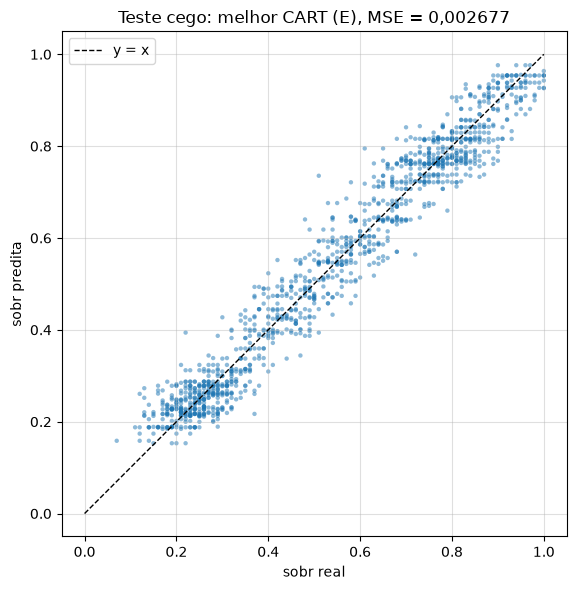

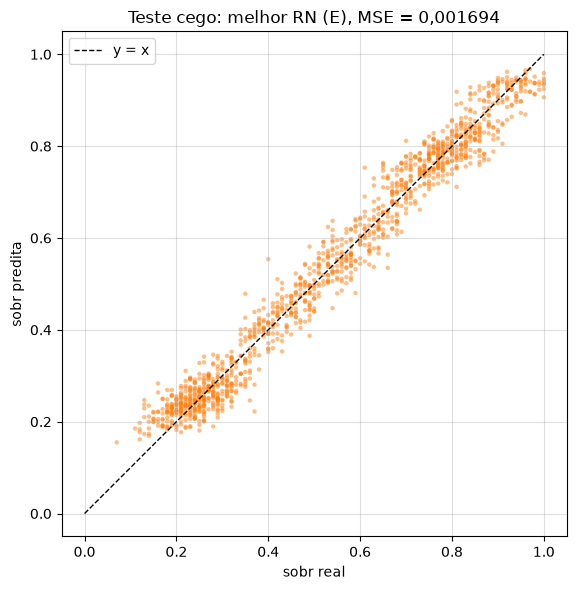

In [8]:
def fmt(valor, casas=6):
    # Número com vírgula decimal
    return f"{valor:.{casas}f}".replace('.', ',')

def dispersao(modelo, rotulo, cor):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_teste, pred[modelo], s=10, alpha=0.5, color=cor, edgecolors='none')
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='y = x')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    ax.set_xlabel("sobr real")
    ax.set_ylabel("sobr predita")
    ax.set_title(f"Teste cego: melhor {modelo} ({rotulo}), MSE = {fmt(mse[modelo])}")
    ax.legend(loc='upper left')
    ax.grid(alpha=0.4)
    fig.tight_layout()

    # PNG em base64 para o relatório (sem metadados, para o arquivo não mudar entre execuções)
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=110, metadata={'Software': None})
    plt.show()
    return base64.b64encode(buffer.getvalue()).decode('ascii')

grafico = {
    'CART': dispersao('CART', melhor_cart, 'tab:blue'),
    'RN': dispersao('RN', melhor_rn, 'tab:orange'),
}

**(9) Tabelas do relatório**

Montamos as tabelas 1 a 7 no formato do enunciado, com vírgula decimal, 6 casas para MSE, RMSE e dpa e 2 casas para o ganho %. A idade (média e dpa) vai com 2 casas.

* Tabelas 3 e 5: média (dpa) por hiperparametrização
* Tabela 6: copia as colunas do melhor modelo das tabelas 3 e 5 (conferido com `assert`)
* Tabela 7: o ganho % só aparece na coluna do melhor entre CART e RN; na outra fica "—"

In [9]:
def fmt_param(valor):
    # Hiperparâmetro como texto: None/str/int como estão, float com vírgula e sem notação científica
    if isinstance(valor, float):
        return np.format_float_positional(valor, trim='-').replace('.', ',')
    if isinstance(valor, list):
        return '[' + ' '.join(str(v) for v in valor) + ']'
    return str(valor)

def media_dpa(r):
    return f"{fmt(r['media'])} ({fmt(r['dpa'])})"

MSE_BARRA = '<span class="barra">MSE</span>'
LINHAS_CV = [
    ('mse_treino', f'TREINO {MSE_BARRA} (dpa)'),
    ('mse_validacao', f'VALIDAÇÃO {MSE_BARRA} (dpa)'),
    ('difs', 'MÉDIA DAS DIFS. (dpa)'),
]
ROTULOS = ['U', 'E', 'O']

# Tabela 1
cores_tri = ['verde', 'amarelo', 'vermelho', 'preto']
tabela1 = [[f'Vítimas tri={cor}', str(dataset_res['tri'][cor])] for cor in cores_tri] + [
    ['Idade das vítimas', fmt(dataset_res['idade']['media'], 2)],
    ['Desvio padrão amostral da idade', fmt(dataset_res['idade']['dpa'], 2)],
    ['ruído', fmt_param(dataset_res['ruido'])],
]

# Tabela 2
hps_cart = cart_res['hiperparametrizacoes']
tabela2 = [[nome] + [fmt_param(hps_cart[r][chave]) for r in ROTULOS] for nome, chave in [
    ('Min_samples_leaf', 'min_samples_leaf'),
    ('Max_depth', 'max_depth'),
    ('Random_state', 'random_state'),
]]

# Tabelas 3 e 5
def tabela_cv(res):
    return [[nome] + [media_dpa(res['resultados'][r][chave]) for r in ROTULOS] for chave, nome in LINHAS_CV]

tabela3 = tabela_cv(cart_res)
tabela5 = tabela_cv(rn_res)

# Tabela 4
hps_rn = rn_res['hiperparametrizacoes']
tabela4 = [[nome] + [fmt_param(hps_rn[r][chave]) for r in ROTULOS] for nome, chave in [
    ('Topologia', 'hidden_layer_sizes'),
    ('Função de ativação', 'activation'),
    ('Learning rate', 'learning_rate_init'),
    ('solver', 'solver'),
    ('Momentum', 'momentum'),
    ('Alpha (L2)', 'alpha'),
    ('Batch_size', 'batch_size'),
    ('Max_iter', 'max_iter'),
    ('Tol', 'tol'),
    ('N_iter_no_change', 'n_iter_no_change'),
    ('Random_state', 'random_state'),
]]

# Tabela 6: cópia das colunas do melhor modelo das tabelas 3 e 5
tabela6 = [[nome, media_dpa(cart_res['resultados'][melhor_cart][chave]),
            media_dpa(rn_res['resultados'][melhor_rn][chave])] for chave, nome in LINHAS_CV]
for i in range(len(LINHAS_CV)):
    assert tabela6[i][1] == tabela3[i][1 + ROTULOS.index(melhor_cart)]
    assert tabela6[i][2] == tabela5[i][1 + ROTULOS.index(melhor_rn)]

# Tabela 7
def celula_ganho(modelo, melhor, valor):
    return f"{fmt(valor, 2)}%" if modelo == melhor else '—'

NOTA_GANHO = '<br><span class="nota">(somente para o melhor entre CART e RN)</span>'
tabela7 = [
    ['MSE', fmt(mse['CART']), fmt(mse['RN'])],
    ['Ganho % de MSE' + NOTA_GANHO,
     celula_ganho('CART', melhor_mse, ganho_mse), celula_ganho('RN', melhor_mse, ganho_mse)],
    ['RMSE', fmt(rmse['CART']), fmt(rmse['RN'])],
    ['Ganho % de RMSE' + NOTA_GANHO,
     celula_ganho('CART', melhor_rmse, ganho_rmse), celula_ganho('RN', melhor_rmse, ganho_rmse)],
]
assert tabela7[0][1:] == [fmt(mse_disco['CART']), fmt(mse_disco['RN'])]

for titulo, t in [('Tabela 6', tabela6), ('Tabela 7', tabela7)]:
    print(titulo)
    for linha in t:
        print('\t'.join(c.replace(MSE_BARRA, 'MSE').replace(NOTA_GANHO, '') for c in linha))
    print()

Tabela 6
TREINO MSE (dpa)	0,001968 (0,000013)	0,001629 (0,000005)
VALIDAÇÃO MSE (dpa)	0,002614 (0,000058)	0,001680 (0,000026)
MÉDIA DAS DIFS. (dpa)	0,000646 (0,000062)	0,000051 (0,000030)

Tabela 7
MSE	0,002677	0,001694
Ganho % de MSE	—	36,72%
RMSE	0,051744	0,041161
Ganho % de RMSE	—	20,45%



**(10) Geração do `relatorio.html`**

O relatório contém **unicamente** as tabelas 1 a 7 e os gráficos de dispersão (seção 8), com os títulos do enunciado e sem nenhum texto adicional. Ele é autocontido: o CSS está no próprio arquivo e os gráficos estão embutidos como PNG em base64, então abre offline. O PDF sai por "Imprimir → Salvar como PDF" no navegador (passo humano).

In [10]:
CSS = '''
body { font-family: Calibri, Carlito, Arial, sans-serif; font-size: 11pt; color: #000; background: #fff;
       max-width: 820px; margin: 24px auto; padding: 0 16px; }
h2 { font-size: 11pt; font-weight: bold; margin: 22px 0 4px; page-break-after: avoid; break-after: avoid; }
p.sub { font-style: italic; font-size: 10pt; margin: 0 0 4px; }
table { border-collapse: collapse; margin-bottom: 8px; page-break-inside: avoid; }
th, td { border: 1px solid #000; padding: 2px 10px; }
th { font-weight: bold; text-align: center; }
td { text-align: center; }
td:first-child { text-align: left; }
table.cv td:first-child, table.t7 td:first-child { text-align: center; font-size: 9pt; }
.barra { text-decoration: overline; font-style: italic; }
.nota { font-size: 9pt; }
.dataset th, .cart th { background: #dbe5f1; }
.rn th { background: #fbe4d5; }
.melhor th { background: #e36c0a; color: #fff; }
.t7 th { background: #b2a1c7; }
.secao8 { page-break-inside: avoid; break-inside: avoid; }
.graficos { display: flex; flex-wrap: wrap; gap: 12px; }
.graficos img { width: calc(50% - 6px); min-width: 280px; height: auto; }
@media print { body { margin: 0 auto; } }
'''

def tabela_html(cabecalho, linhas, classe):
    # O texto das células já vem pronto (números e rótulos gerados aqui, sem entrada externa)
    th = ''.join(f'<th>{c}</th>' for c in cabecalho)
    trs = ''.join('<tr>' + ''.join(f'<td>{c}</td>' for c in linha) + '</tr>' for linha in linhas)
    return f'<table class="{classe}"><thead><tr>{th}</tr></thead><tbody>{trs}</tbody></table>'

secoes = [
    '<h2>1) DATASET DE TREINAMENTO/VALIDAÇÃO</h2>',
    tabela_html(['MODELO', 'VALOR'], tabela1, 'dataset'),
    '<h2>2) HIPERPARAMETRIZAÇÕES CART</h2>',
    tabela_html(['MODELO', 'U', 'E', 'O'], tabela2, 'cart'),
    '<h2>3) RESULTADOS DOS MODELOS CART</h2>',
    '<p class="sub">Médias dos MSEs com desvio padrão amostral por fold por hiperparametrização (U, E, O)</p>',
    tabela_html(['MODELO', 'CART U', 'CART E', 'CART O'], tabela3, 'cart cv'),
    '<h2>4) HIPERPARAMETRIZAÇÕES REDE NEURAL</h2>',
    tabela_html(['MODELO', 'U', 'E', 'O'], tabela4, 'rn'),
    '<h2>5) RESULTADOS DOS MODELOS RN</h2>',
    tabela_html(['MODELO', 'RN U', 'RN E', 'RN O'], tabela5, 'rn cv'),
    '<h2>6) MELHOR MODELO CART X MELHOR MODELO RN</h2>',
    tabela_html(['MODELO', f'Melhor CART ({melhor_cart})', f'Melhor RN ({melhor_rn})'], tabela6, 'melhor cv'),
    '<h2>7) RESULTADOS DO TESTE CEGO: MELHOR CART X MELHOR RN</h2>',
    tabela_html(['MODELO', f'Melhor CART ({melhor_cart})', f'Melhor RN ({melhor_rn})'], tabela7, 't7'),
    '<div class="secao8"><h2>8) GRÁFICO DE DISPERSÃO</h2><div class="graficos">' + ''.join(
        f'<img alt="Dispersão real x predito: melhor {m}" src="data:image/png;base64,{grafico[m]}">'
        for m in ['CART', 'RN']) + '</div></div>',
]

relatorio = ('<!DOCTYPE html>\n<html lang="pt-BR">\n<head>\n<meta charset="utf-8">\n'
             '<meta name="viewport" content="width=device-width, initial-scale=1">\n'
             '<title>Tarefa 2: Regressão</title>\n'
             f'<style>{CSS}</style>\n</head>\n<body>\n' + '\n'.join(secoes) + '\n</body>\n</html>\n')

RELATORIO_HTML.write_text(relatorio, encoding='utf-8')

# Autocontido: nenhuma referência externa (só imagens data:)
assert 'http' not in relatorio
assert relatorio.count('src="') == relatorio.count('src="data:image/png;base64,') == 2
# Os MSE do teste cego e os ganhos estão no relatório
for valor in [fmt(mse['CART']), fmt(mse['RN']), fmt(ganho_mse, 2), fmt(ganho_rmse, 2)]:
    assert valor in relatorio

print(f"Relatório gravado em {RELATORIO_HTML} ({RELATORIO_HTML.stat().st_size / 1024:.0f} KB)")
# Mostra as tabelas aqui (sem o CSS, que alteraria a página do notebook; os gráficos já estão acima)
display(HTML('\n'.join(secoes[:-1])))

Relatório gravado em results/relatorio.html (227 KB)
